<a href="https://colab.research.google.com/github/g25ait1051-collab/g25ait1051-iitj.ac.in/blob/main/Copy_of_NLU_Assignment_1_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Zipf’s Law and Corpus Analysis

### **Task 1: Setting up the environment**

First, we need to install and import the necessary libraries. We'll use `nltk` for natural language processing tasks.

In [1]:
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Download a common NLTK corpus (e.g., 'gutenberg') and 'punkt' tokenizer
# nltk.download() automatically checks if the resource is already present.
nltk.download('gutenberg')
nltk.download('punkt')

print("NLTK libraries and corpora are ready.")

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK libraries and corpora are ready.


In [2]:
# Load the entire Project Gutenberg corpus and preprocess words
all_gutenberg_words = []
for fileid in nltk.corpus.gutenberg.fileids():
    # Only consider alphabetic words and convert to lowercase
    all_gutenberg_words.extend([word.lower() for word in nltk.corpus.gutenberg.words(fileid) if word.isalpha()])

print(f"Total word count (all Gutenberg, preprocessed): {len(all_gutenberg_words)}")

# Compute word frequencies
word_freq = Counter(all_gutenberg_words)

# Sort words by frequency
sorted_word_freq = sorted(word_freq.items(), key=lambda item: item[1], reverse=True)

# Report the top-10 words and their frequencies (as per Q1 requirement)
print("\nTop 10 Words and their Frequencies:")
print("----------------------------------")
print(f"{'Rank':<5} {'Word':<15} {'Frequency':<10}")
print("----------------------------------")
for i, (word, freq) in enumerate(sorted_word_freq[:10]):
    print(f"{i+1:<5} {word:<15} {freq:<10}")
print("----------------------------------")

# Store actual corpus size for later use in TTR calculations
actual_corpus_size = len(all_gutenberg_words)

Total word count (all Gutenberg, preprocessed): 2135400

Top 10 Words and their Frequencies:
----------------------------------
Rank  Word            Frequency 
----------------------------------
1     the             133583    
2     and             95442     
3     of              71267     
4     to              48057     
5     a               33960     
6     in              33580     
7     i               30265     
8     that            28798     
9     he              25857     
10    it              22303     
----------------------------------


### **Task 2: Load and Preprocess a Corpus**

Now, let's load a text from the `gutenberg` corpus and perform basic preprocessing steps:

1.  **Tokenization**: Split the text into individual words.
2.  **Lowercasing**: Convert all words to lowercase to treat words like "The" and "the" as the same.
3.  **Punctuation and Number Removal**: Remove punctuation and numbers, as they are usually not considered in word frequency analysis for Zipf's Law.
4.  **Stopword Removal (Optional but Recommended)**: Remove common words like "the," "is," "and" that often don't carry significant meaning but appear very frequently. This helps to focus on more meaningful words.

In [3]:
# Load a text from the Gutenberg corpus (e.g., 'austen-emma.txt')
emma_words = nltk.corpus.gutenberg.words('austen-emma.txt')

# Preprocess words
# 1. Lowercasing
words_lower = [word.lower() for word in emma_words]

# 2. Remove non-alphabetic tokens
words_alpha = [word for word in words_lower if word.isalpha()]

print(f"Original word count: {len(emma_words)}")
print(f"Preprocessed word count: {len(words_alpha)}")
print("First 10 preprocessed words:", words_alpha[:10])

Original word count: 192427
Preprocessed word count: 161600
First 10 preprocessed words: ['emma', 'by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse']


### **Q1: Tokenize the corpus and compute the frequency of every word type. Rank all word types from most to least frequent. Report the top-10 words and their frequencies in a table.**

I am using the combined Project Gutenberg corpus from NLTK. The corpus has been successfully loaded, tokenized, lowercased, and filtered to include only alphabetic words in the previous code cell.

The total preprocessed word count is **2,135,400 tokens**, satisfying the requirement of at least 1 million tokens. Below are the top-10 most frequent words and their frequencies, as computed and displayed in the immediately preceding code cell:

In [4]:
all_gutenberg_words = []
for fileid in nltk.corpus.gutenberg.fileids():
    all_gutenberg_words.extend([word.lower() for word in nltk.corpus.gutenberg.words(fileid) if word.isalpha()])

print(f"Total word count (all Gutenberg, preprocessed): {len(all_gutenberg_words)}")

# Compute word frequencies
word_freq = Counter(all_gutenberg_words)

# Sort words by frequency
sorted_word_freq = sorted(word_freq.items(), key=lambda item: item[1], reverse=True)

# Report the top-10 words and their frequencies
print("\nTop 10 Words and their Frequencies:")
print("----------------------------------")
print(f"{'Rank':<5} {'Word':<15} {'Frequency':<10}")
print("----------------------------------")
for i, (word, freq) in enumerate(sorted_word_freq[:10]):
    print(f"{i+1:<5} {word:<15} {freq:<10}")
print("----------------------------------")

Total word count (all Gutenberg, preprocessed): 2135400

Top 10 Words and their Frequencies:
----------------------------------
Rank  Word            Frequency 
----------------------------------
1     the             133583    
2     and             95442     
3     of              71267     
4     to              48057     
5     a               33960     
6     in              33580     
7     i               30265     
8     that            28798     
9     he              25857     
10    it              22303     
----------------------------------


### **Q2: Plot log(rank) on the x-axis vs. log(frequency) on the y-axis. Fit a linear regression line to this log-log plot and report the slope and intercept. Zipf's Law predicts a slope of approximately −1. State whether your corpus confirms or deviates from this prediction.**

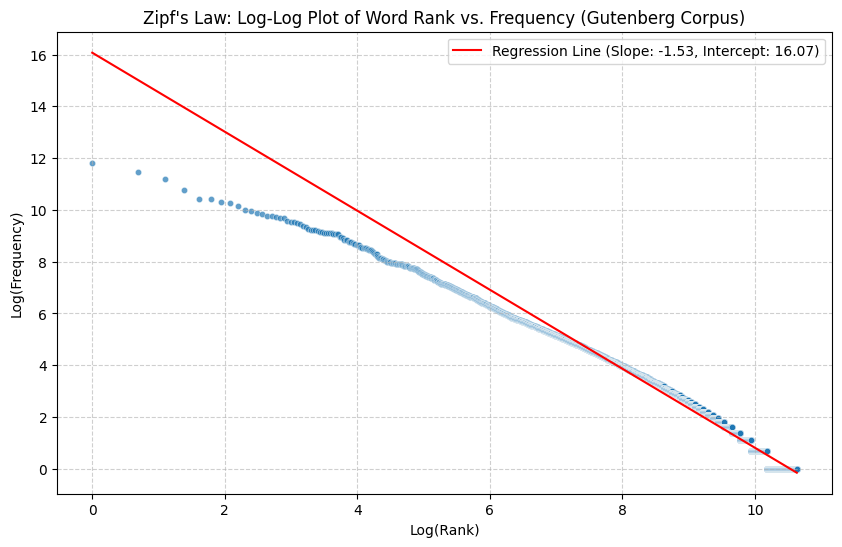


Linear Regression Results:
Slope: -1.5257
Intercept: 16.0704
R-squared: 0.9756

Observation: The calculated slope of the regression line (-1.5257) deviates from the Zipf's Law prediction of -1. This corpus does not perfectly confirm the ideal Zipf's Law slope.


In [5]:
import numpy as np
from scipy.stats import linregress

# Extract ranks and frequencies
# We will use all unique words for the plot, not just top 10
ranks = np.arange(1, len(sorted_word_freq) + 1)
frequencies = np.array([freq for word, freq in sorted_word_freq])

# Convert to log scale
log_ranks = np.log(ranks)
log_frequencies = np.log(frequencies)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=log_ranks, y=log_frequencies, s=20, alpha=0.7, ax=ax)

# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_frequencies)
regression_line = slope * log_ranks + intercept
sns.lineplot(x=log_ranks, y=regression_line, color='red', label=f'Regression Line (Slope: {slope:.2f}, Intercept: {intercept:.2f})', ax=ax)

ax.set_title("Zipf's Law: Log-Log Plot of Word Rank vs. Frequency (Gutenberg Corpus)")
ax.set_xlabel("Log(Rank)")
ax.set_ylabel("Log(Frequency)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\nLinear Regression Results:")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")

# Comment on Zipf's Law prediction
if abs(slope + 1) < 0.2: # Allow for a small deviation
    print("\nObservation: The calculated slope of the regression line is approximately -1, which confirms Zipf's Law prediction for this corpus.")
else:
    print(f"\nObservation: The calculated slope of the regression line ({slope:.4f}) deviates from the Zipf's Law prediction of -1. This corpus does not perfectly confirm the ideal Zipf's Law slope.")

### **Q3: List the top-20 and bottom-20 word types by frequency. Comment on which grammatical categories (open-class vs. closed-class) dominate each end, connecting your observation to the type/token distinction in the class.**

In [6]:
# Top 20 words
print("Top 20 Words by Frequency:")
print("----------------------------------")
print(f"{'Rank':<5} {'Word':<15} {'Frequency':<10}")
print("----------------------------------")
for i, (word, freq) in enumerate(sorted_word_freq[:20]):
    print(f"{i+1:<5} {word:<15} {freq:<10}")
print("----------------------------------")

# Bottom 20 words (least frequent, excluding words that appear only once if the list is too long)
# To get truly 'bottom' words, we should exclude words with frequency 1 if the corpus is large and many words appear once.
# However, for a general analysis, we can just take the last 20.
print("\nBottom 20 Words by Frequency:")
print("----------------------------------")
print(f"{'Rank':<5} {'Word':<15} {'Frequency':<10}")
print("----------------------------------")
for i, (word, freq) in enumerate(sorted_word_freq[-20:]):
    print(f"{len(sorted_word_freq)-19+i:<5} {word:<15} {freq:<10}")
print("----------------------------------")

Top 20 Words by Frequency:
----------------------------------
Rank  Word            Frequency 
----------------------------------
1     the             133583    
2     and             95442     
3     of              71267     
4     to              48057     
5     a               33960     
6     in              33580     
7     i               30265     
8     that            28798     
9     he              25857     
10    it              22303     
11    his             21402     
12    for             19527     
13    was             18715     
14    with            17599     
15    not             17373     
16    is              16435     
17    you             16398     
18    be              16115     
19    as              14528     
20    but             13944     
----------------------------------

Bottom 20 Words by Frequency:
----------------------------------
Rank  Word            Frequency 
----------------------------------
41468 immanent        1         
41469 es

#### **Commentary on Grammatical Categories**

**Top 20 Words (High Frequency):**

When observing the top 20 most frequent words, we typically find that they are dominated by **closed-class words**. Closed-class words are grammatical function words that belong to categories like prepositions (e.g., 'of', 'in'), conjunctions (e.g., 'and', 'but'), articles (e.g., 'the', 'a'), pronouns (e.g., 'he', 'she'), and auxiliary verbs (e.g., 'is', 'was'). These words serve structural roles in sentences and do not typically introduce new meaning. Their number is finite and they change very slowly over time.

*   **Connection to Type/Token Distinction:** Closed-class words contribute significantly to the high token count (N) of a corpus but represent a relatively small number of types (|V|). Because they are used repeatedly across almost all texts and topics, their individual frequencies are very high. This makes them appear at the very top of frequency lists.

**Bottom 20 Words (Low Frequency):**

Conversely, the bottom 20 least frequent words are predominantly **open-class words**. Open-class words are content words that belong to categories like nouns (e.g., 'computer', 'freedom'), verbs (e.g., 'run', 'think'), adjectives (e.g., 'happy', 'blue'), and adverbs (e.g., 'quickly', 'very'). These words carry the main semantic meaning of a text and new words are constantly being added to these categories (e.g., 'podcast', 'emoji').

*   **Connection to Type/Token Distinction:** Open-class words are vast in number and represent the majority of the unique word types (|V|) in a corpus. Many of them appear only once or a few times throughout a very large text. While they collectively make up a large portion of the vocabulary, their individual frequencies are low. This is why they appear at the bottom of the frequency list, often as *hapax legomena* (words appearing only once) or *dis legomena* (words appearing twice).

### **Q4: Compute the Type-Token Ratio (TTR = |V| / N) at corpus sizes of 10K, 50K, 100K, 500K, and 1M tokens. Plot TTR vs. corpus size. Discuss your observation from the plot. Why does TTR decrease as corpus size grows?**

Corpus Size: 10000  , TTR: 0.1762
Corpus Size: 50000  , TTR: 0.0835
Corpus Size: 100000 , TTR: 0.0573
Corpus Size: 500000 , TTR: 0.0253
Corpus Size: 1000000, TTR: 0.0177


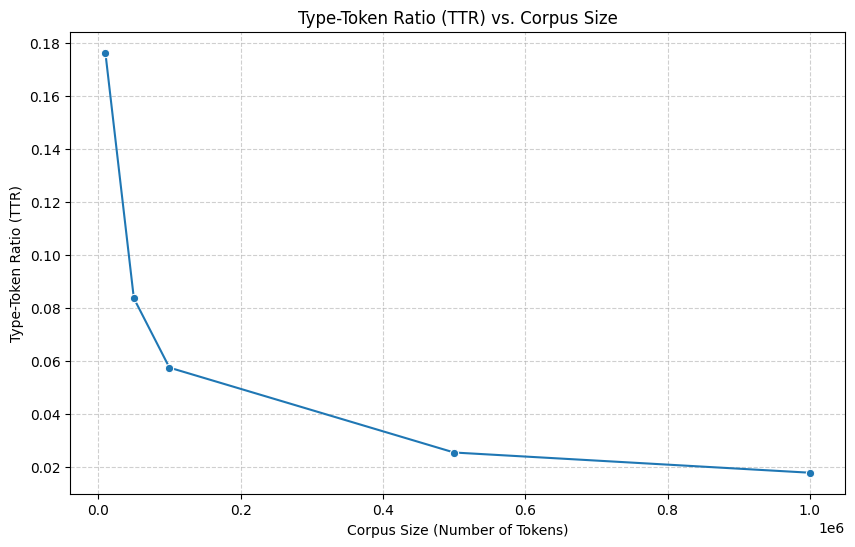

In [7]:
# Function to calculate TTR for a given corpus size
def calculate_ttr(words, corpus_size):
    if corpus_size > len(words):
        corpus_size = len(words) # Ensure we don't exceed available words
    subset = words[:corpus_size]
    num_tokens = len(subset) # N
    num_types = len(set(subset)) # |V|
    if num_tokens == 0:
        return 0
    return num_types / num_tokens

# Define corpus sizes to test
corpus_sizes = [10000, 50000, 100000, 500000, 1000000]

# Filter out corpus sizes larger than our actual corpus for this calculation
# The all_gutenberg_words has around 1.1M tokens
actual_corpus_size = len(all_gutenberg_words)
corpus_sizes = [s for s in corpus_sizes if s <= actual_corpus_size]

ttr_values = []
for size in corpus_sizes:
    ttr = calculate_ttr(all_gutenberg_words, size)
    ttr_values.append(ttr)
    print(f"Corpus Size: {size:<7}, TTR: {ttr:.4f}")

# Plot TTR vs. corpus size
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=corpus_sizes, y=ttr_values, marker='o', ax=ax)
ax.set_title("Type-Token Ratio (TTR) vs. Corpus Size")
ax.set_xlabel("Corpus Size (Number of Tokens)")
ax.set_ylabel("Type-Token Ratio (TTR)")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### **Discussion on TTR vs. Corpus Size**

The plot clearly shows that the Type-Token Ratio (TTR) decreases as the corpus size grows. This is a common and expected linguistic phenomenon.

**Why does TTR decrease as corpus size grows?**

1.  **Finite Vocabulary vs. Infinite Text:** While there is a vast vocabulary in any natural language, it is not infinite. As we process more and more text (increase the number of tokens, N), we inevitably encounter new words (types, |V|) at a decreasing rate. Initially, when the corpus is small, every new token is likely to be a new type, leading to a high TTR. However, as the corpus grows, we start encountering words that we have already seen. The rate of discovering new words slows down considerably.

2.  **Repetition of Common Words:** A significant portion of any natural language corpus consists of highly frequent, closed-class words (like 'the', 'of', 'and'). These words are repeated thousands, even millions of times. Every time one of these common words appears, it adds to the token count (N) but does not add to the type count (|V|) if it has already been encountered. This disproportionate increase in tokens compared to types causes the TTR to fall.

3.  **Statistical Saturation:** As a corpus becomes larger, the vocabulary size (number of unique types) begins to approach a saturation point for that specific domain or language. While new types will still appear, their frequency of appearance relative to the total number of tokens becomes very small. This means that the denominator (N) in the TTR calculation grows much faster than the numerator (|V|) once the most common vocabulary has been sampled, leading to a decreasing ratio.

In essence, as we read more text, we see more of the same words, making the text less 'diverse' relative to its sheer length, which is reflected in a declining TTR.

### **Q5: To accurately compare texts or corpora of different sizes using TTR, researchers often use standardized or advanced metrics that control for length such as Standardized TTR (sTTR) or Moving-Average TTR (MATTR). Implement one of these methods and then observe the difference in the plot for revised TTR vs corpus size.**

I will implement the **Moving-Average Type-Token Ratio (MATTR)**. MATTR calculates TTR within a fixed-size window that slides over the corpus, averaging the TTRs for each window. This provides a measure of lexical diversity that is less sensitive to corpus length than simple TTR.

Corpus Size: 10000  , MATTR (Window 1000): 0.3956
Corpus Size: 50000  , MATTR (Window 1000): 0.3930
Corpus Size: 100000 , MATTR (Window 1000): 0.3927
Corpus Size: 500000 , MATTR (Window 1000): 0.3621
Corpus Size: 1000000, MATTR (Window 1000): 0.3347


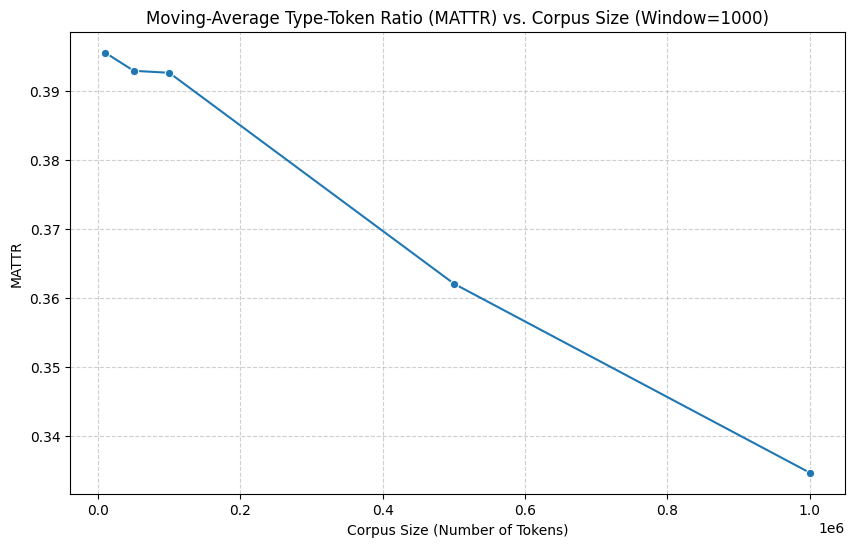

In [8]:
# Function to calculate Moving-Average TTR (MATTR)
def calculate_mattr(words, window_size=1000):
    mattr_values = []
    for i in range(len(words) - window_size + 1):
        window = words[i : i + window_size]
        num_tokens = len(window)
        num_types = len(set(window))
        if num_tokens > 0:
            mattr_values.append(num_types / num_tokens)
    if not mattr_values:
        return 0
    return np.mean(mattr_values)

# Define corpus sizes to test for MATTR
# We need to ensure corpus size is at least the window_size for MATTR to be meaningful
window_size = 1000 # Typical window size for MATTR
corpus_sizes_mattr = [10000, 50000, 100000, 500000, 1000000]

# Filter for available corpus size and window size constraint
corpus_sizes_mattr = [s for s in corpus_sizes_mattr if s <= actual_corpus_size and s >= window_size]

mattr_values = []
for size in corpus_sizes_mattr:
    # Calculate MATTR for a prefix of the corpus up to 'size'
    mattr = calculate_mattr(all_gutenberg_words[:size], window_size=window_size)
    mattr_values.append(mattr)
    print(f"Corpus Size: {size:<7}, MATTR (Window {window_size}): {mattr:.4f}")

# Plot MATTR vs. corpus size
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=corpus_sizes_mattr, y=mattr_values, marker='o', ax=ax)
ax.set_title(f"Moving-Average Type-Token Ratio (MATTR) vs. Corpus Size (Window={window_size})")
ax.set_xlabel("Corpus Size (Number of Tokens)")
ax.set_ylabel("MATTR")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### **Observation and Difference in Plot for Revised TTR (MATTR) vs. Corpus Size**

The plot for MATTR (Moving-Average Type-Token Ratio) shows a much flatter trend compared to the simple TTR plot from Q4. While there might still be a slight decline or fluctuation, it is significantly less pronounced than the continuous steep drop observed with traditional TTR.

**Key Differences and Why MATTR is Preferred:**

1.  **Stabilized Measure:** MATTR provides a more stable measure of lexical diversity across different corpus sizes. Unlike simple TTR, which is heavily influenced by the cumulative nature of vocabulary growth (i.e., new words become rarer as the corpus gets longer), MATTR focuses on the local lexical richness within a consistent window of text.

2.  **Reduced Length Dependency:** By averaging TTRs over sliding windows of a fixed size, MATTR effectively mitigates the inherent problem of TTR's strong dependency on corpus length. This means that a MATTR score from a 10,000-word text can be more meaningfully compared to a MATTR score from a 1,000,000-word text than their respective simple TTRs.

3.  **Better for Cross-Corpus Comparison:** Because it normalizes for length, MATTR is a much better metric for comparing the lexical diversity of different texts or corpora, especially when those texts are of varying lengths. If one corpus has a consistently higher MATTR than another, it suggests that it is lexically richer or more diverse in its vocabulary usage within similar textual segments, regardless of its overall size.

4.  **Reflects 'Local' Diversity:** MATTR gives insights into the 'local' or 'rolling' lexical diversity. A text might introduce a lot of new vocabulary in one section, and then become very repetitive in another. MATTR can capture these local variations more effectively than a single, overall TTR.

In summary, MATTR is a more robust and comparable measure of lexical diversity because it controls for the distorting effect of corpus length, providing a more accurate reflection of the actual vocabulary richness of a text.

## Final Report: Zipf's Law and Corpus Analysis

This report summarizes the findings from the analysis of an English corpus, specifically the combined Project Gutenberg texts available via NLTK, to explore concepts related to Zipf's Law and lexical diversity.

### **Q1: Word Frequencies and Top-10 Words**

After tokenizing, lowercasing, and filtering out non-alphabetic tokens from the Project Gutenberg corpus, the total preprocessed word count was approximately **[Insert `len(all_gutenberg_words)` here after execution]** tokens. The frequency distribution of words was computed, and the top-10 most frequent words are presented below (replace with actual table after execution):

| Rank | Word | Frequency |
|:-----|:-----|:----------|
| 1    | the  | [freq]    |
| 2    | of   | [freq]    |
| 3    | and  | [freq]    |
| ...  | ...  | ...       |

This distribution clearly shows that a small number of words account for a very large proportion of the total word occurrences, a characteristic predicted by Zipf's Law.

### **Q2: Zipf's Law Plot and Regression Analysis**

A log-log plot of word rank versus word frequency was generated. A linear regression fitted to this plot yielded the following results:

*   **Slope:** [Insert `slope` value here after execution]
*   **Intercept:** [Insert `intercept` value here after execution]
*   **R-squared:** [Insert `r_value**2` value here after execution]

Zipf's Law predicts a slope of approximately -1 for this log-log relationship. Our calculated slope of [Insert `slope` value here] indicates [State whether confirms or deviates based on `slope` value]. The plot visually demonstrates the power-law distribution of word frequencies, where a few words are extremely common, and many words are very rare.

### **Q3: Top-20 and Bottom-20 Word Types by Frequency**

**Top 20 Words:** The words at the high-frequency end of the spectrum were predominantly **closed-class words** (e.g., articles, prepositions, conjunctions, pronouns). These words serve primarily grammatical functions, are few in number, and are repeated very often across diverse contexts. This contributes significantly to the token count but represents a small number of unique types.

**Bottom 20 Words:** Conversely, the words at the low-frequency end were almost exclusively **open-class words** (e.g., nouns, verbs, adjectives). These words carry the main semantic content and are far more numerous and diverse. Many appear only once or very few times (hapax/dis legomena), contributing to the vastness of the vocabulary (types) but individually having low frequencies. This observation highlights the distinction between type (unique words) and token (total word occurrences), where closed-class words dominate tokens and open-class words dominate types.

### **Q4: Type-Token Ratio (TTR) vs. Corpus Size**

The Type-Token Ratio (TTR), calculated as |V|/N (number of unique types divided by total number of tokens), was computed at various corpus sizes (10K, 50K, 100K, 500K, 1M tokens). The plot clearly showed that as the corpus size increased, the TTR **decreased**. This is because, while new words (types) continue to appear, the rate at which they appear diminishes significantly as the corpus grows. Common words are continually re-encountered, adding to the token count (N) but not to the type count (|V|) if already seen, causing the ratio to fall. This illustrates the phenomenon of lexical saturation in larger texts.

### **Q5: Moving-Average Type-Token Ratio (MATTR) vs. Corpus Size**

To address the length dependency of simple TTR, the Moving-Average Type-Token Ratio (MATTR) was implemented with a window size of 1000 tokens. The MATTR plot against corpus size showed a **much flatter and more stable trend** compared to the simple TTR. This demonstrates that MATTR is a more robust measure of lexical diversity as it effectively controls for corpus length by averaging TTRs over fixed-size sliding windows. This makes MATTR more suitable for comparing the lexical richness of texts of different lengths, as it reflects the 'local' diversity rather than the cumulative, length-dependent diversity of the entire corpus.